In [ ]:
!pip install pandas numpy matplotlib seaborn scipy networkx

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
import networkx as nx

In [4]:
df = pd.read_csv("merged_vft_spam_responses.csv")

print(df.head())
print(df.columns)

   subject_id            session_id   domain  position    word language_type  \
0       10255  1qmxoH7jT7VECeLUVEKU  colours         1     red       English   
1       10255  1qmxoH7jT7VECeLUVEKU  colours         2    blue       English   
2       10255  1qmxoH7jT7VECeLUVEKU  colours         3   green       English   
3       10255  1qmxoH7jT7VECeLUVEKU  colours         4  indigo       English   
4       10255  1qmxoH7jT7VECeLUVEKU  colours         5  orange       English   

    rt_ms         x         y  
0  2558.3  0.076446  1.003870  
1  1464.6  0.080923  0.540248  
2  1505.6  0.074953  0.097112  
3  1894.6  0.125355  0.534443  
4  1583.3  0.119329  1.003870  
Index(['subject_id', 'session_id', 'domain', 'position', 'word',
       'language_type', 'rt_ms', 'x', 'y'],
      dtype='object')


In [5]:
df = df[df["language_type"] != "English"]

In [6]:
print(df["language_type"].value_counts())

language_type
Hindi/Hinglish    699
Englishs            1
Name: count, dtype: int64


In [7]:
import os
os.makedirs("plots", exist_ok=True)

In [8]:
results = []

groups = df.groupby(["subject_id", "domain"])

for (subject, domain), group in groups:

    if len(group) < 2:
        continue

    words = group["word"].values
    coords = group[["x", "y"]].values

    # ---------- Distance Matrix ----------
    
    dist_matrix = squareform(pdist(coords, metric="euclidean"))
    
    pairwise_distances = dist_matrix[np.triu_indices(len(coords), 1)]

    mean_distance = np.mean(pairwise_distances)
    min_distance = np.min(pairwise_distances)
    max_distance = np.max(pairwise_distances)

    # ---------- Neighborhood Metric ----------
    
    mean_neighbor_distance = dist_matrix.mean(axis=1)

    # ---------- Cluster Detection ----------
    
    threshold = np.median(pairwise_distances)

    G = nx.Graph()

    for i in range(len(words)):
        G.add_node(words[i])

    for i in range(len(words)):
        for j in range(i+1, len(words)):
            if dist_matrix[i, j] <= threshold:
                G.add_edge(words[i], words[j])

    clusters = list(nx.connected_components(G))

    cluster_sizes = [len(c) for c in clusters]

    num_clusters = len(clusters)
    mean_cluster_size = np.mean(cluster_sizes)

    # ---------- Save Summary ----------
    
    results.append({
        "subject_id": subject,
        "domain": domain,
        "n_words": len(words),
        "mean_distance": mean_distance,
        "min_distance": min_distance,
        "max_distance": max_distance,
        "clusters": num_clusters,
        "mean_cluster_size": mean_cluster_size
    })

    # ---------- Scatter Plot (Spatial Map) ----------
    
    plt.figure(figsize=(6,6))

    plt.scatter(group["x"], group["y"])

    for i, word in enumerate(words):
        plt.text(coords[i,0], coords[i,1], word)

    plt.title(f"SpAM Map: Subject {subject} - {domain}")
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.savefig(f"plots/spam_map_{subject}_{domain}.png")
    plt.close()

    # ---------- Histogram of Distances ----------
    
    plt.figure()

    sns.histplot(pairwise_distances, bins=10)

    plt.title(f"Distance Distribution\nSubject {subject} - {domain}")

    plt.xlabel("Semantic Distance")

    plt.savefig(f"plots/distance_hist_{subject}_{domain}.png")
    plt.close()

C:\Users\ommeh\AppData\Local\Temp\ipykernel_20440\1675195311.py:74: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"plots/spam_map_{subject}_{domain}.png")
C:\Users\ommeh\AppData\Local\Temp\ipykernel_20440\1675195311.py:74: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.savefig(f"plots/spam_map_{subject}_{domain}.png")
C:\Users\ommeh\AppData\Local\Temp\ipykernel_20440\1675195311.py:74: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.savefig(f"plots/spam_map_{subject}_{domain}.png")
C:\Users\ommeh\AppData\Local\Temp\ipykernel_20440\1675195311.py:74: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"plots/spam_map_{subject}_{domain}.png")
C:\Users\ommeh\AppData\Local\Temp\ipykernel_20440\1675195311.py:74: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"plo

In [9]:
summary_df = pd.DataFrame(results)

print(summary_df.head())

   subject_id      domain  n_words  mean_distance  min_distance  max_distance  \
0        3342     animals        7       0.392383      0.102257      0.872529   
1        3342  body-parts        7       0.205174      0.073400      0.445461   
2        3342       foods        7       0.186265      0.075952      0.317912   
3        5157     animals        9       0.279467      0.039518      0.681382   
4        5157  body-parts       10       0.172535      0.044433      0.361234   

   clusters  mean_cluster_size  
0         1                7.0  
1         1                7.0  
2         1                7.0  
3         2                4.5  
4         1               10.0  


In [10]:
summary_df.to_csv("spam_summary_metrics.csv", index=False)

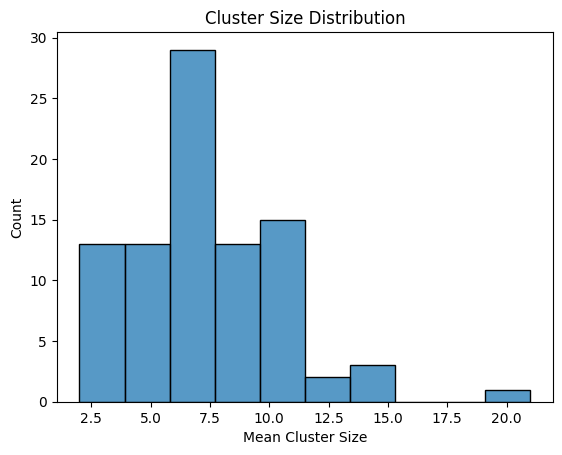

In [13]:
plt.figure()

sns.histplot(summary_df["mean_cluster_size"], bins=10)

plt.title("Cluster Size Distribution")

plt.xlabel("Mean Cluster Size")

# plt.savefig("plots/cluster_size_distribution.png")

plt.show()
plt.close()

In [14]:
plt.figure()

sns.boxplot(x=summary_df["mean_distance"])

plt.title("Mean Semantic Distance Across Participants")

plt.savefig("plots/mean_distance_boxplot.png")
plt.close()

In [15]:
stats = summary_df.describe()

print(stats)

stats.to_csv("spam_descriptive_statistics.csv")

         subject_id    n_words  mean_distance  min_distance  max_distance  \
count     89.000000  89.000000      89.000000     89.000000     89.000000   
mean   53208.808989   7.842697       0.291608      0.088957      0.536124   
std    29355.949513   2.992031       0.149255      0.124041      0.224298   
min     3342.000000   2.000000       0.074338      0.002482      0.133159   
25%    25803.000000   6.000000       0.180276      0.042561      0.350277   
50%    61476.000000   7.000000       0.277326      0.056079      0.550571   
75%    78839.000000  10.000000       0.329910      0.073400      0.657771   
max    95712.000000  21.000000       0.919380      0.919380      1.216725   

        clusters  mean_cluster_size  
count  89.000000          89.000000  
mean    1.157303           7.207865  
std     0.366149           3.296700  
min     1.000000           2.000000  
25%     1.000000           5.000000  
50%     1.000000           7.000000  
75%     1.000000           9.000000  
ma